In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

playground_series_s6e4_path = kagglehub.competition_download('playground-series-s6e4')

print('Data source import complete.')


100%|██████████| 32.5M/32.5M [00:00<00:00, 161MB/s]

Extracting files...


Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
path=playground_series_s6e4_path
files = os.listdir(path)
print("今回のコンペでダウンロードされたファイル一覧:")
for f in files:
  print(f"- {f}")


今回のコンペでダウンロードされたファイル一覧:
- sample_submission.csv
- train.csv
- test.csv


In [ ]:
target_file = "sample_submission.csv"
df = pd.read_csv(os.path.join(playground_series_s6e4_path, target_file))
df.head()

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


In [ ]:
#データ読み込み
train=pd.read_csv(os.path.join(playground_series_s6e4_path, 'train.csv'))
test_original=pd.read_csv(os.path.join(playground_series_s6e4_path, 'test.csv'))

# test_id を保存
test_id = test_original['id']

# 処理のためにコピーを作成
test = test_original.copy()

train.columns

Index(['id', 'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need'],
      dtype='object')

In [ ]:
train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [ ]:
# 不要な列
drop_cols = ['id']
train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
!pip install catboost
from catboost import CatBoostClassifier, Pool

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [ ]:
def create_extra_features(df):
    # 1. 水分需給バランス
    #df['Water_Energy_Index'] = (df['Temperature_C'] * df['Sunlight_Hours']) / (df['Humidity'] + 1)

    # 2. 成長段階の重要度（季節との組み合わせ）
    #df['Growth_Context'] = df['Crop_Type'].astype(str) + "_" + df['Crop_Growth_Stage'].astype(str)

    # 3. 風の影響
    #df['Wind_Temp_Interaction'] = df['Wind_Speed_kmh'] * df['Temperature_C']

    #土壌水分を4つのグループに分ける
    #df['Moisture_band']=pd.qcut(df['Soil_Moisture'], q=4, labels=False)


    # 灌漑が必要な可能性を高めるスコア (High score)
    df['high_score'] = 0
    df.loc[df['Soil_Moisture'] < 25, 'high_score'] += 2
    df.loc[df['Rainfall_mm'] < 300, 'high_score'] += 2
    df.loc[df['Temperature_C'] > 30, 'high_score'] += 1
    df.loc[df['Wind_Speed_kmh'] > 10, 'high_score'] += 1

    # 灌漑が不要な可能性を高めるスコア (Low score)
    df['low_score'] = 0
    df.loc[df['Crop_Growth_Stage'] == 'Harvest', 'low_score'] += 2
    df.loc[df['Crop_Growth_Stage'] == 'Sowing', 'low_score'] += 2
    df.loc[df['Mulching_Used'] == 'Yes', 'low_score'] += 1

    # 総合スコア
    df['formula_score'] = df['high_score'] - df['low_score']

    # スコアに基づく予測ラベル（これをモデルに直接教える）
    df['formula_pred'] = 'Medium'
    df.loc[df['formula_score'] > 0, 'formula_pred'] = 'High'
    df.loc[df['formula_score'] < 0, 'formula_pred'] = 'Low'

    # 作物による補正 (Rice, Sugarcane, Bananaなどは水需要が高い)

    thirsty_crops = ['Rice', 'Sugarcane', 'Banana']
    df.loc[df['Crop_Type'].isin(thirsty_crops), 'high_score'] += 1

    # 成長段階による補正 (Vegetative: 栄養成長期は水が必要)
    df.loc[df['Crop_Growth_Stage'] == 'Vegetative', 'high_score'] += 0.5

    # これにより Low になりすぎるのを防いでMediumを多くする
    df.loc[df['Mulching_Used'] == 'Yes', 'low_score'] -= 0.5

    # 雨が多くても(>1000)、土が乾いている(<20)or暑すぎる(>35)なら加点
    df.loc[(df['Rainfall_mm'] > 1000) & ((df['Soil_Moisture'] < 20) | (df['Temperature_C'] > 35)), 'high_score'] += 1.0

    # 3. 特定の地域（Region）の乾燥補正
    # エラーデータに多い地域（例：WestやNorthなど）があれば微調整
    df.loc[df['Region'] == 'West', 'high_score'] += 0.5

    # Vegetative
    df.loc[df['Crop_Growth_Stage'] == 'Vegetative', 'high_score'] += 1.5

    # Flowering
    df.loc[df['Crop_Growth_Stage'] == 'Flowering', 'high_score'] += 1.2


    # 低湿度の時の Flowering はさらに危険なので加点
    df.loc[(df['Crop_Growth_Stage'] == 'Flowering') & (df['Humidity'] < 40), 'high_score'] += 0.5

    #スコアの最終確定
    df['formula_score'] = df['high_score'] - df['low_score']

    #判定ラベルの出力
    df['formula_pred'] = 'Medium'
    df.loc[df['formula_score'] > 0.5, 'formula_pred'] = 'High'
    df.loc[df['formula_score'] < -1, 'formula_pred'] = 'Low'
    return df

train = create_extra_features(train)
test = create_extra_features(test)

cat_features = train.select_dtypes(include=['object']).columns.tolist()
print(f"Category Features: {cat_features}")

/tmp/ipykernel_3423/327188090.py:42: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.5 1.5 4.5 ... 3.5 6.5 2.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Crop_Growth_Stage'] == 'Vegetative', 'high_score'] += 0.5
/tmp/ipykernel_3423/327188090.py:46: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.5 0.5 0.5 ... 0.5 0.5 0.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Mulching_Used'] == 'Yes', 'low_score'] -= 0.5
/tmp/ipykernel_3423/327188090.py:42: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[4.5 2.5 2.5 ... 2.5 0.5 2.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Crop_

Category Features: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region', 'Irrigation_Need', 'formula_pred']


In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def add_mathematical_features(train_df, test_df):
    # 1. 数値データの抽出と標準化
    # センサーデータなど、数値の列だけを指定
    num_cols = ['Soil_Moisture', 'Temperature_C', 'Humidity', 'Wind_Speed_kmh', 'Sunlight_Hours']

    scaler = StandardScaler()
    train_num_scaled = scaler.fit_transform(train_df[num_cols])
    test_num_scaled = scaler.transform(test_df[num_cols])

    #K-means
    n_clusters = 5
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

    train_df['Cluster_ID'] = kmeans.fit_predict(train_num_scaled).astype(str) # カテゴリとして扱う
    test_df['Cluster_ID'] = kmeans.predict(test_num_scaled).astype(str)

    #PCA (主成分分析)
    # 5つの数値を、情報の密度が高い「2つの合成変数」に凝縮する
    pca = PCA(n_components=2, random_state=42)
    train_pca = pca.fit_transform(train_num_scaled)
    test_pca = pca.transform(test_num_scaled)

    train_df['PCA_1'] = train_pca[:, 0] # 第1主成分
    train_df['PCA_2'] = train_pca[:, 1] # 第2主成分
    test_df['PCA_1'] = test_pca[:, 0]
    test_df['PCA_2'] = test_pca[:, 1]

    return train_df, test_df

# 実行
train, test = add_mathematical_features(train, test)

if 'Cluster_ID' not in cat_features:
    cat_features.append('Cluster_ID')

In [ ]:
print(train['Irrigation_Need'].value_counts(dropna=False))

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64


In [ ]:
features = [col for col in train.columns if col not in ['id', 'Irrigation_Need']]
target_map = {'Low': 0, 'Medium': 1, 'High': 2}
# X と X_test を同じ列構成で作る
X = train[features]
y = train['Irrigation_Need'].map(target_map)

X_test = test[features]

In [ ]:
# 文字列型の列名を取得
cat_features = X.select_dtypes(include=['object']).columns.tolist()
print(f"Category Features: {cat_features}")

Category Features: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region', 'formula_pred', 'Cluster_ID']


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
!pip install optuna
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.7 MB/s eta 0:00:00


In [ ]:
def objective(trial):
    # 探索するパラメータの範囲
    params = {
    'learning_rate': 0.07966478890229094,
    'depth': 5,
    'l2_leaf_reg': 4.585052325393321,
    'random_strength': 3.7299239940542472,
    'bagging_temperature': 0.5659468003635836,
    'loss_function': 'MultiClass',
    'eval_metric': 'Accuracy',
    'iterations': 2000,
    'random_seed': 42,
    'task_type': 'GPU'  # GPUを使う場合
}
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_val, y_val), early_stopping_rounds=50)

    # 検証データでの精度を評価
    preds = model.predict(X_val)
    return accuracy_score(y_val, preds)

In [ ]:
## 最適化のセッションを作成
#study = optuna.create_study(direction="maximize")
# n_trialsはまずは20〜50回程度で試してみるのがオススメです
#study.optimize(objective, n_trials=30)

#print("Best Score:", study.best_value)
#print("Best Params:", study.best_params)

In [ ]:
import lightgbm as lgb

# カテゴリ変数を 'category' 型に変換
for col in cat_features:
    X[col] = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 再度分割（型変換を反映させるため）
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

/tmp/ipykernel_3423/634336746.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')
/tmp/ipykernel_3423/634336746.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')
/tmp/ipykernel_3423/634336746.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

In [ ]:
# 各特徴量に対する重みをリストで作成する

weights_dict = {
    'formula_score': 5,
    'formula_pred': 5,
    'high_score': 2,
    'low_score': 2
}
# X.columns の各列に対して重みを割り当て
feature_weights = [weights_dict.get(col, 1.0) for col in X.columns]
# LGBMのパラメータ（これまでの傾向に合わせた推奨値）
lgbm_params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'learning_rate': 0.05,
    'max_depth': 6,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'feature_weight': feature_weights,
    'random_state': 42,
    'n_estimators': 2000,
    'device': 'cpu' # GPUを使う場合
}

# モデルの定義
lgbm_model = lgb.LGBMClassifier(**lgbm_params)

# 学習
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.0618317
Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_logloss: 0.0618317


LGBMClassifier(bagging_fraction=0.8613803043338393, bagging_freq=2,
               device='cpu', feature_fraction=0.7756090847879809,
               feature_weight=[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,
                               1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2,
                               2, 5, 5, 1.0, 1.0, 1.0],
               learning_rate=0.040697581364491746, max_depth=14,
               metric='multi_logloss', min_child_samples=40, num_class=3,
               num_leaves=155, objective='multiclass', random_state=42,
               verbosity=-1)

In [ ]:

# 1. パラメータを定義
my_params = {
    'learning_rate': 0.07966478890229094,
    'depth': 5,
    'l2_leaf_reg': 4.585052325393321,
    'random_strength': 3.7299239940542472,
    'bagging_temperature': 0.5659468003635836,
    'loss_function': 'MultiClass',
    'eval_metric': 'Accuracy',
    'iterations': 2000,
    'random_seed': 42,
    'task_type': 'CPU'  # GPUを使う場合
}

# 特徴量の名前に合わせて重みを設定
weights = {
    'formula_score': 5.0,  # 5倍重視
    'formula_pred': 5.0,   # 5倍重視
    'high_score': 2.0,
    'low_score': 2.0
}

# 全ての特徴量リストに対して重みを割り当て（指定がないものは1.0）
feature_weights = [weights.get(col, 1.0) for col in X.columns]

model = CatBoostClassifier(
    **my_params,
    feature_weights=feature_weights, # ここで重みを指定
    verbose=100
)

cat_features_for_fit = [f for f in cat_features if f in X_train.columns]

# 学習
model.fit(
    X_train, y_train,
    cat_features=cat_features_for_fit,
    eval_set=(X_val, y_val),    # 検証データ
    use_best_model=True,
    early_stopping_rounds=50
)

0:	learn: 0.8980377	test: 0.8996349	best: 0.8996349 (0)	total: 3.63s	remaining: 2h 1m 5s
100:	learn: 0.9732738	test: 0.9734365	best: 0.9734365 (100)	total: 5m 40s	remaining: 1h 46m 33s
200:	learn: 0.9845198	test: 0.9844524	best: 0.9844603 (195)	total: 11m 8s	remaining: 1h 39m 40s
300:	learn: 0.9850020	test: 0.9849603	best: 0.9849683 (299)	total: 16m 48s	remaining: 1h 34m 51s
400:	learn: 0.9851845	test: 0.9851032	best: 0.9851032 (387)	total: 22m 24s	remaining: 1h 29m 20s
500:	learn: 0.9852579	test: 0.9851905	best: 0.9851905 (488)	total: 27m 56s	remaining: 1h 23m 35s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9852063492
bestIteration = 521

Shrink model to first 522 iterations.


CatBoostClassifier(bagging_temperature=0.5659468003635836, depth=5, eval_metric='Accuracy', feature_weights=[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 5.0, 5.0, 1.0, 1.0, 1.0], iterations=2000, l2_leaf_reg=4.585052325393321, learning_rate=0.07966478890229094, loss_function='MultiClass', random_seed=42, random_strength=3.7299239940542472, task_type='CPU', verbose=100)

In [ ]:
# バリデーション評価
preds = model.predict(X_val)
print(classification_report(y_val, preds))

# テストデータでの予測
test_preds = model.predict(X_test)

# 提出用ファイルの作成
submission = pd.read_csv(os.path.join(playground_series_s6e4_path, 'sample_submission.csv'))
reverse_map = {0: 'Low', 1: 'Medium', 2: 'High'}
submission['Irrigation_Need'] = [reverse_map[p[0]] for p in test_preds]
submission.to_csv('baseline_submission.csv', index=False)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     73983
           1       0.99      0.98      0.98     47815
           2       0.97      0.90      0.93      4202

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000



In [ ]:
# 各モデルで「確率（predict_proba）」を出す

# CatBoostの予測結果を評価
# 確率からクラスラベルに変換して評価
# print(classification_report(y_val, preds))
# LGBMの予測結果
lgbm_val_probs = lgbm_model.predict_proba(X_val) # バリデーションデータで確率を出す
lgbm_val_preds = lgbm_val_probs.argmax(axis=1) # 確率から予測クラスに変換
print("LGBM Validation Report:")
print(classification_report(y_val, lgbm_val_preds))

# 5:5 でブレンド
# CatBoostの予測確率（eval_setで使われたX_valに対するもの）
catboost_val_probs = model.predict_proba(X_val)

# アンサンブルの予測確率（バリデーションセット）
final_val_probs = (catboost_val_probs + lgbm_val_probs) / 2
final_val_preds = final_val_probs.argmax(axis=1)
print("Ensemble Validation Report:")
print(classification_report(y_val, final_val_preds))

# テストデータでの予測
# LGBMのテスト予測確率
lgbm_test_probs = lgbm_model.predict_proba(X_test)
# LGBMのテスト予測クラス
lgbm_test_preds = lgbm_test_probs.argmax(axis=1)

# アンサンブルのテスト予測（CatBoostのテスト予測確率とLGBMのテスト予測確率をブレンド）
final_test_probs = (model.predict_proba(X_test) + lgbm_test_probs) / 2
final_test_preds = final_test_probs.argmax(axis=1)

# 提出用ファイルの作成 (LGBM単体)
submission = pd.read_csv(os.path.join(playground_series_s6e4_path, 'sample_submission.csv'))
reverse_map = {0: 'Low', 1: 'Medium', 2: 'High'}

# LGBMのテストセットに対する予測結果を代入
submission['Irrigation_Need'] = [reverse_map[p] for p in lgbm_test_preds]

submission.to_csv('lgbm_submission.csv', index=False) # ファイル名を変更

# CatBoostのテスト予測で提出
submission_catboost = pd.read_csv(os.path.join(playground_series_s6e4_path, 'sample_submission.csv'))
submission_catboost['Irrigation_Need'] = [reverse_map[p[0]] for p in model.predict(X_test)]
submission_catboost.to_csv('catboost_submission.csv', index=False)

# アンサンブルで提出する
submission_ensemble = pd.read_csv(os.path.join(playground_series_s6e4_path, 'sample_submission.csv'))
submission_ensemble['Irrigation_Need'] = [reverse_map[p] for p in final_test_preds]
submission_ensemble.to_csv('ensemble_submission.csv', index=False)

LGBM Validation Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     73983
           1       0.99      0.98      0.98     47815
           2       0.97      0.91      0.94      4202

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000

Ensemble Validation Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     73983
           1       0.99      0.98      0.98     47815
           2       0.97      0.90      0.94      4202

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000



In [ ]:
import optuna
import lightgbm as lgb
from sklearn.metrics import accuracy_score

# def objective(trial):
#     param = {
#         'objective': 'multiclass',
#         'num_class': 3,
#         'metric': 'multi_logloss',
#         'verbosity': -1,
#         'boosting_type': 'gbdt',
#         'random_state': 42,
#         'device': 'cpu', # GPU使用時

#         # 最適化したい範囲を指定
#         'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
#         'num_leaves': trial.suggest_int('num_leaves', 31, 256),
#         'max_depth': trial.suggest_int('max_depth', 5, 15),
#         'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
#         'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
#         'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
#         'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),

#         # あなたが設定した feature_weight もここで渡す
#         'feature_weight': feature_weights
#     }

#     # 学習（簡易的な分割例）
#     model = lgb.LGBMClassifier(**param)
#     model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(stopping_rounds=50)])

#     preds = model.predict(X_val)
#     accuracy = accuracy_score(y_val, preds)
#     return accuracy

# # 最適化の実行
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50) # 50回ほど試行

# print('Best trial:', study.best_trial.params)

#スコアは上がらなかった

[I 2026-04-07 06:44:15,308] A new study created in memory with name: no-name-0352f953-f7d3-473f-90be-d18630ebafbd


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_logloss: 0.104873


[I 2026-04-07 06:45:32,540] Trial 0 finished with value: 0.9849682539682539 and parameters: {'learning_rate': 0.01785678938269675, 'num_leaves': 220, 'max_depth': 9, 'min_child_samples': 67, 'feature_fraction': 0.9360409147760927, 'bagging_fraction': 0.7094753179331414, 'bagging_freq': 7}. Best is trial 0 with value: 0.9849682539682539.


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_logloss: 0.0684009


[I 2026-04-07 06:46:10,985] Trial 1 finished with value: 0.9850873015873016 and parameters: {'learning_rate': 0.03252852343517417, 'num_leaves': 155, 'max_depth': 10, 'min_child_samples': 45, 'feature_fraction': 0.5889682960737354, 'bagging_fraction': 0.5852759226754779, 'bagging_freq': 5}. Best is trial 1 with value: 0.9850873015873016.


...

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_logloss: 0.0700987


[I 2026-04-07 07:19:44,469] Trial 48 finished with value: 0.9848650793650794 and parameters: {'learning_rate': 0.04421964668308403, 'num_leaves': 133, 'max_depth': 5, 'min_child_samples': 62, 'feature_fraction': 0.8848161568865409, 'bagging_fraction': 0.894079018946434, 'bagging_freq': 2}. Best is trial 42 with value: 0.9852698412698413.


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_logloss: 0.0691664


[I 2026-04-07 07:20:22,699] Trial 49 finished with value: 0.9850873015873016 and parameters: {'learning_rate': 0.029703751194339878, 'num_leaves': 153, 'max_depth': 12, 'min_child_samples': 49, 'feature_fraction': 0.7468767883991442, 'bagging_fraction': 0.6034137514344093, 'bagging_freq': 1}. Best is trial 42 with value: 0.9852698412698413.


Best trial: {'learning_rate': 0.040697581364491746, 'num_leaves': 155, 'max_depth': 14, 'min_child_samples': 40, 'feature_fraction': 0.7756090847879809, 'bagging_fraction': 0.8613803043338393, 'bagging_freq': 2}


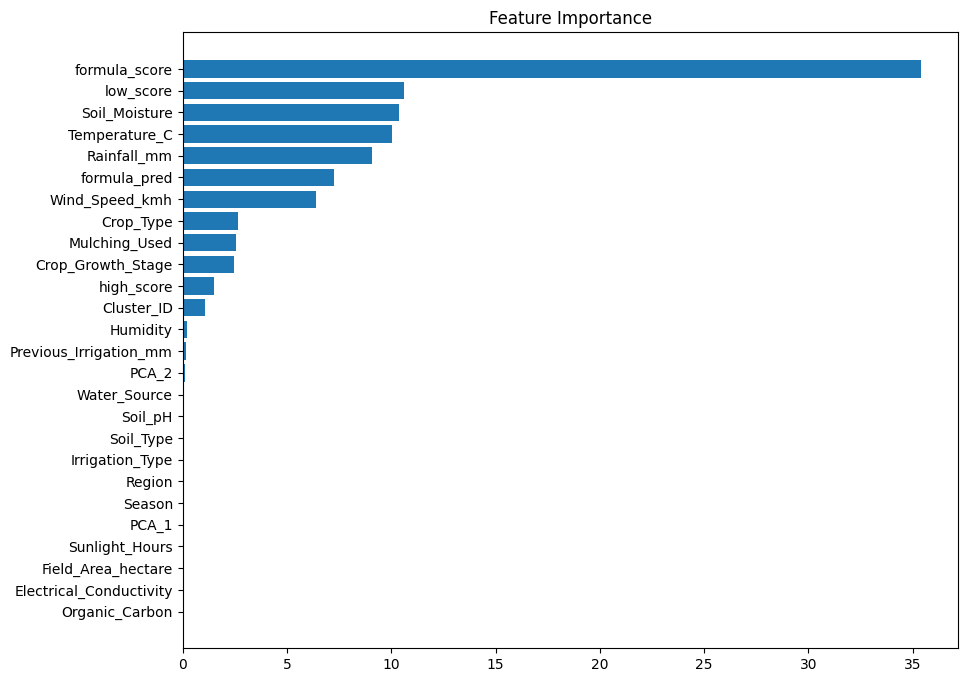

In [ ]:
# 特徴量の重要度を表示
import matplotlib.pyplot as plt

feature_importance = model.get_feature_importance()
feature_names = X.columns
sorted_idx = feature_importance.argsort()

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.title('Feature Importance')
plt.show()

In [ ]:
# 検証データで間違えたものを特定
val_preds = model.predict(X_val)
# 1次元配列に変換（CatBoostの戻り値対策）
val_preds = val_preds.flatten()

error_df = X_val.copy()
error_df['actual'] = y_val.values
error_df['pred'] = val_preds

errors = error_df[error_df['actual'] != error_df['pred']]

print(f"間違いの数: {len(errors)}")
display(errors.head(10))

間違いの数: 1864


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,...,Region,high_score,low_score,formula_score,formula_pred,Cluster_ID,PCA_1,PCA_2,actual,pred
596895,Clay,5.62,48.29,1.15,0.59,18.13,29.32,459.00,9.67,10.37,...,South,2.7,0.5,2.2,High,1,0.583737,-0.817145,1,0
463950,Sandy,5.14,11.12,0.74,2.58,17.60,31.72,1381.78,5.84,2.11,...,West,3.0,2.5,0.5,Medium,1,-0.709938,-1.347736,1,0
43811,Loamy,6.05,10.09,1.27,0.69,31.73,47.63,1705.60,6.12,3.07,...,South,6.0,0.0,6.0,High,0,-1.461134,-1.115562,2,1
317999,Clay,6.80,46.05,0.86,2.21,32.91,74.90,545.26,6.96,2.42,...,South,4.0,0.5,3.5,High,4,0.490358,-0.979564,1,0
48008,Loamy,6.52,11.82,0.92,3.49,34.71,51.63,1292.55,6.23,18.82,...,West,8.0,0.5,7.5,High,3,-2.175700,1.014564,2,1
595171,Silt,6.88,25.87,1.14,2.58,38.04,32.86,1752.31,7.94,13.83,...,North,5.0,0.5,4.5,High,0,-1.883001,-0.456454,0,1
77779,Clay,7.76,20.73,1.25,1.81,39.77,30.38,218.67,8.23,3.68,...,West,5.0,2.0,3.0,High,0,-1.815767,-1.857669,2,1
36302,Clay,6.68,47.75,1.22,0.27,33.64,75.65,127.21,4.06,7.17,...,South,3.0,2.5,0.5,Medium,4,0.155460,-0.395196,1,0
455719,Clay,5.95,20.78,0.76,1.50,34.93,79.98,2062.68,6.93,18.21,...,East,4.0,2.5,1.5,High,3,-1.235440,1.602647,0,1
6926,Clay,7.59,9.66,1.15,1.92,30.55,56.16,16.73,6.57,0.79,...,East,7.0,0.0,7.0,High,4,-1.116114,-1.140359,1,2


In [ ]:
errors.to_csv('model_errors.csv', index=False)
print("'model_errors.csv' としてエクスポートしました")

'model_errors.csv' としてエクスポートしました


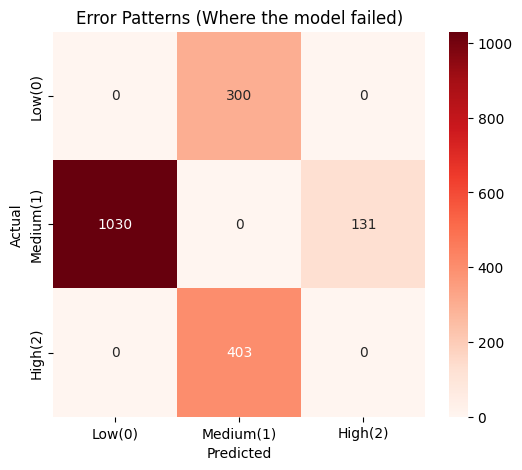

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import pandas as pd

# エラーデータの読み込み
errors = pd.read_csv('model_errors.csv')

# 行列の作成
cm = confusion_matrix(errors['actual'], errors['pred'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Low(0)', 'Medium(1)', 'High(2)'],
            yticklabels=['Low(0)', 'Medium(1)', 'High(2)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Error Patterns (Where the model failed)')
plt.show()

/tmp/ipykernel_3423/1417036635.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_counts.index, y=error_counts.values, ax=axes[i], palette='viridis')
/tmp/ipykernel_3423/1417036635.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_counts.index, y=error_counts.values, ax=axes[i], palette='viridis')
/tmp/ipykernel_3423/1417036635.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_counts.index, y=error_counts.values, ax=axes[i], palette='viridis')
/tmp/ipykernel_3423/1417036635.py:10: FutureWarning: 

Passing `pal

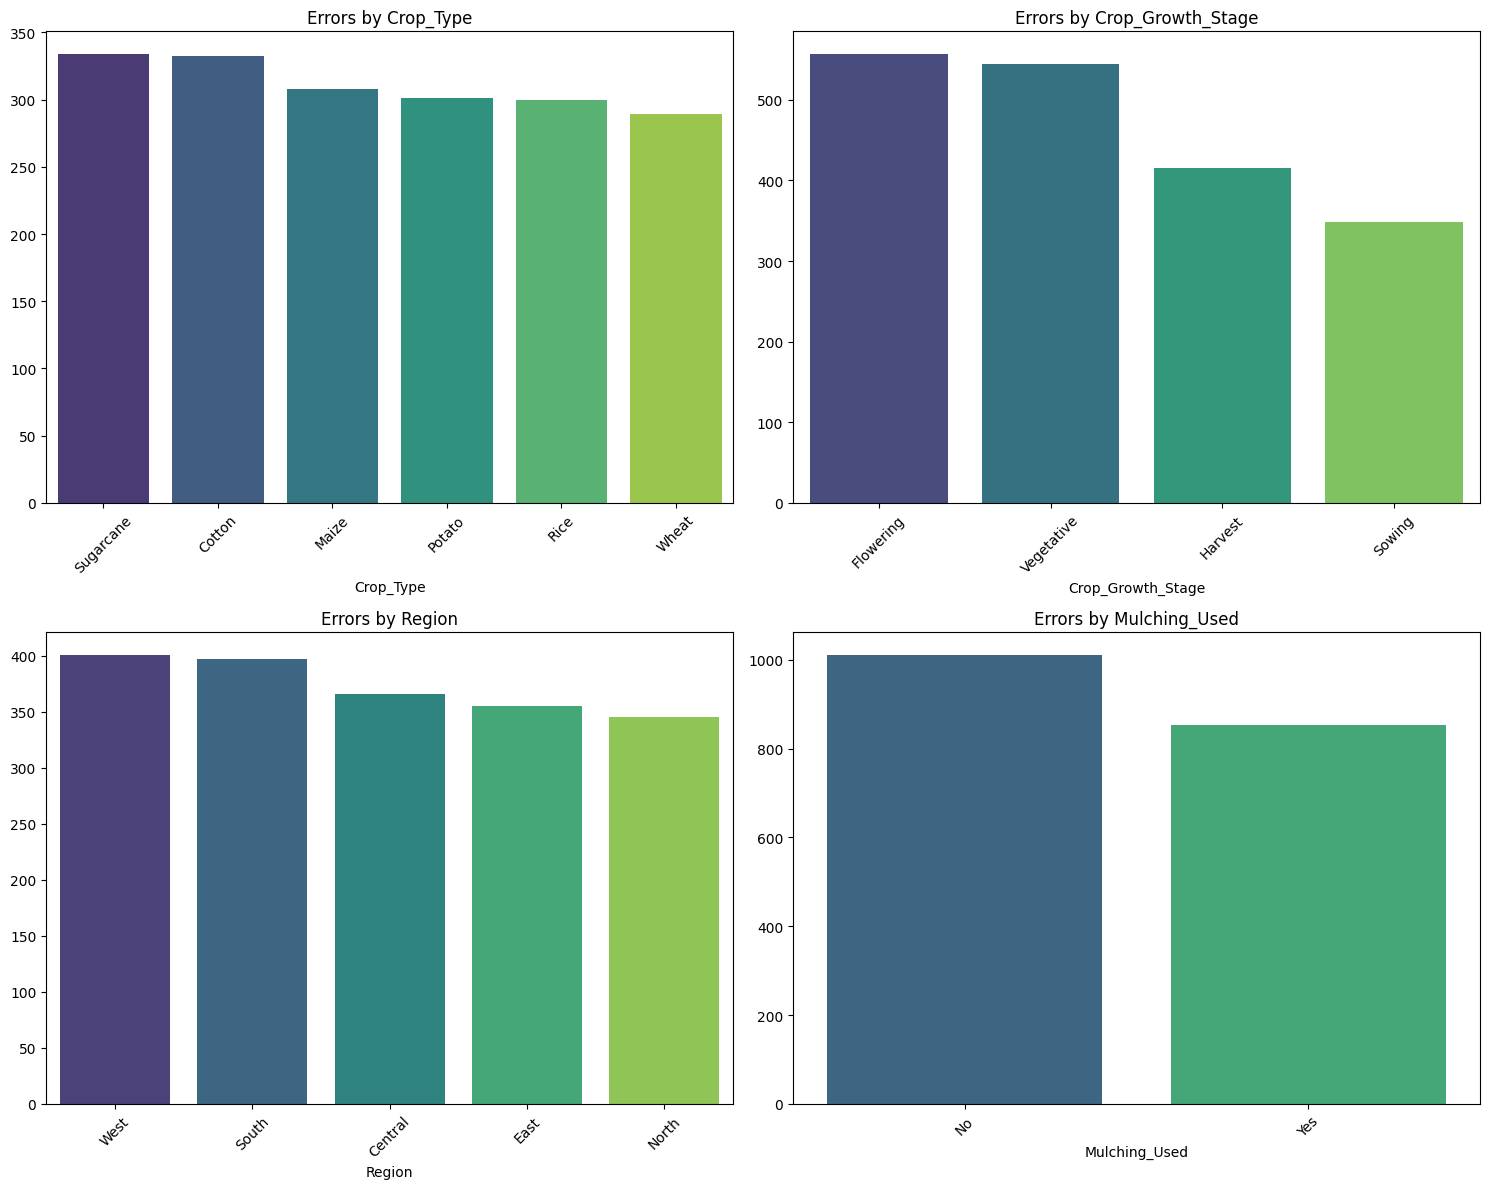

In [ ]:
# 分析したいカテゴリ変数のリスト
cat_cols = ['Crop_Type', 'Crop_Growth_Stage', 'Region', 'Mulching_Used']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # エラーデータ内での各カテゴリの出現頻度
    error_counts = errors[col].value_counts()
    sns.barplot(x=error_counts.index, y=error_counts.values, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Errors by {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3423/4257329228.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_rate.index, y=error_rate.values, ax=axes[i], palette='magma')
/tmp/ipykernel_3423/4257329228.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_rate.index, y=error_rate.values, ax=axes[i], palette='magma')
/tmp/ipykernel_3423/4257329228.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_rate.index, y=error_rate.values, ax=axes[i], palette='magma')
/tmp/ipykernel_3423/4257329228.py:24: FutureWarning: 

Passing `palette` without assi

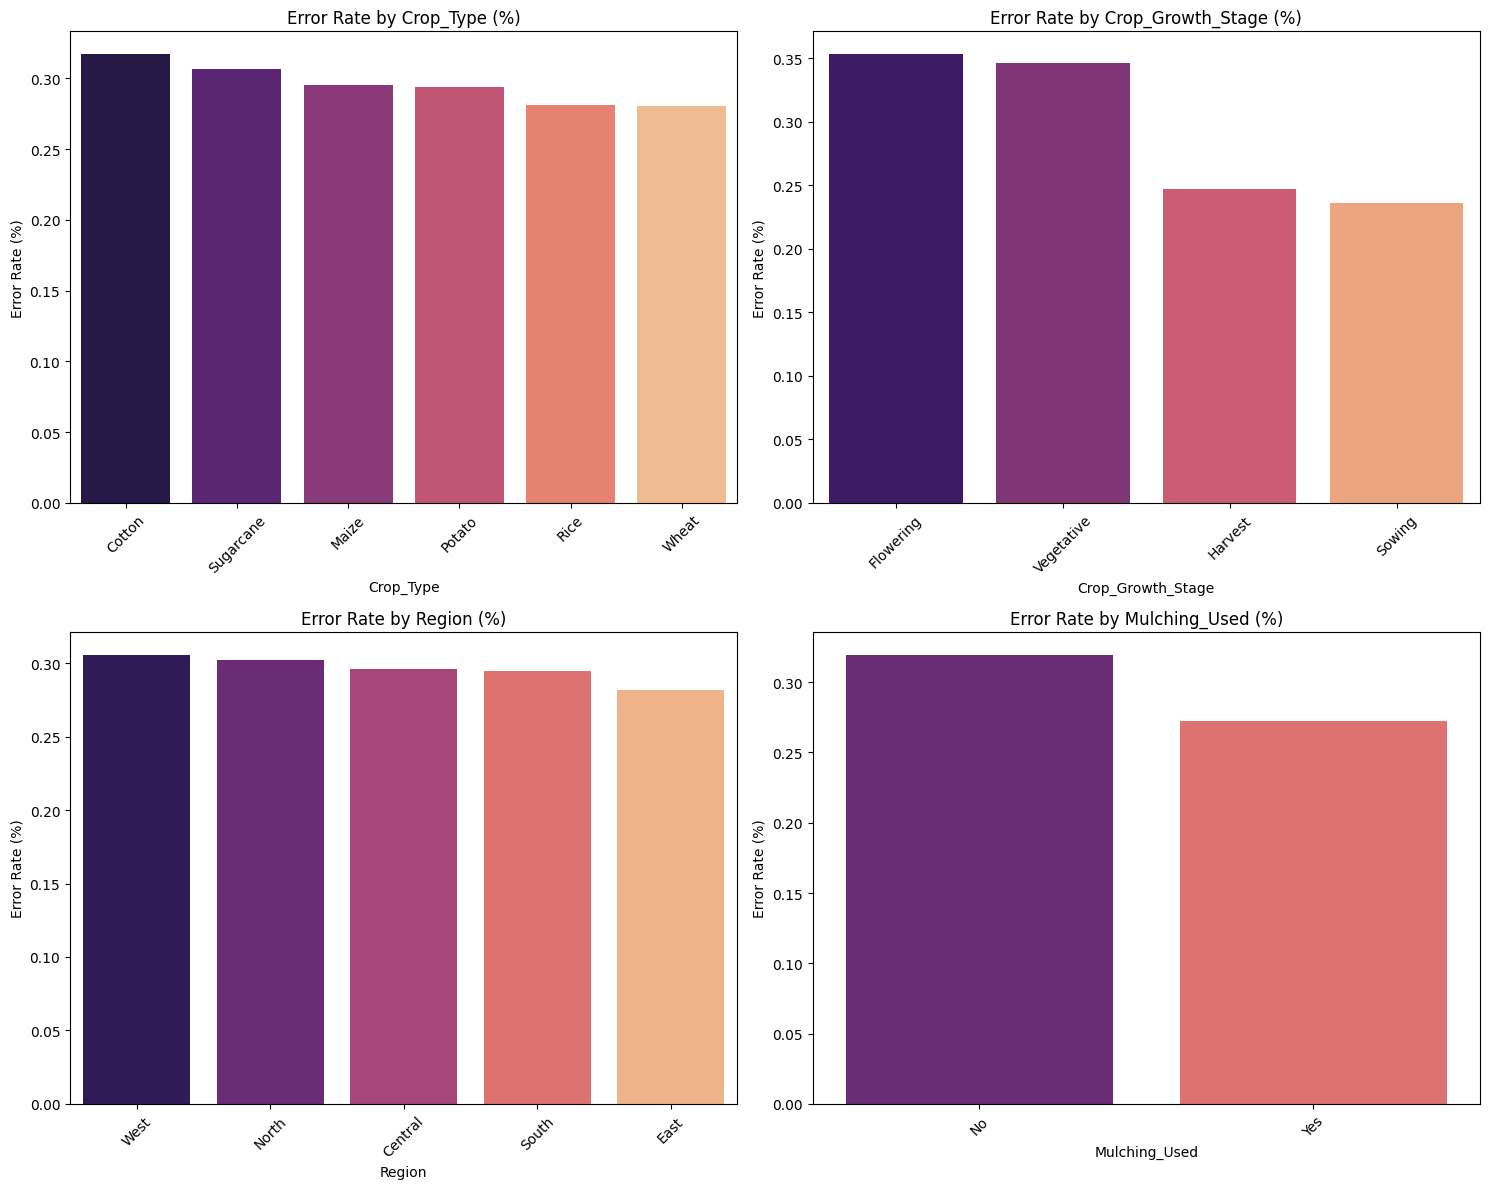

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 分析したいカテゴリ変数のリスト
cat_cols = ['Crop_Type', 'Crop_Growth_Stage', 'Region', 'Mulching_Used']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # 元の全データ(trainまたはX_val)での各カテゴリの件数
    total_counts = train[col].value_counts()

    # エラーデータ内での各カテゴリの件数
    error_counts = errors[col].value_counts()

    # エラー率（割合）を計算 (エラー数 / 全データ数)
    # reindexを使用して計算
    error_rate = (error_counts / total_counts).reindex(total_counts.index).fillna(0) * 100

    # 可視化 (エラー率が高い順にソート)
    error_rate = error_rate.sort_values(ascending=False)
    sns.barplot(x=error_rate.index, y=error_rate.values, ax=axes[i], palette='magma')

    axes[i].set_title(f'Error Rate by {col} (%)')
    axes[i].set_ylabel('Error Rate (%)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     73983
           1       0.98      0.98      0.98     47815
           2       0.96      0.91      0.94      4202

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000